In [1]:
!pip install wordcloud plotly seaborn

#importing the libraries
import pandas as pd #reading
import numpy as np #transformation
import matplotlib.pyplot as plt #visual
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud


In [2]:
# storing dataset in to df variable
df = pd.read_csv('Casino_Gaming_Data new.csv')

# Viewing dataset
print("Original dataset \n")
df.info()
print("\n \n")
print(df.describe())

Original dataset 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 11 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   Fiscal Year                                 143 non-null    object
 1   Month Ending                                143 non-null    object
 2   Licensee                                    143 non-null    object
 3   Wagers                                      143 non-null    int64 
 4   Patron Winnings                             143 non-null    int64 
 5   Cancelled Wagers                            143 non-null    int64 
 6   Online Casino Gaming Win/(Loss)             143 non-null    int64 
 7   Promotional Coupons or Credits Wagered (3)  143 non-null    int64 
 8   Promotional Deduction (4)                   143 non-null    int64 
 9   Total Gross Gaming Revenue                  143 non-null    int64 
 10  Payment

In [3]:
"""
Updated this block to use df.ffill() instead of df.fillna(method='ffill')
The old method works but gives a FutureWarning in newer versions of pandas.
Using df.ffill() is more efficient and future-proof.

# handling missing values in dataset
df.fillna(method='ffill', inplace=True)

# dropping duplicates values from dataset
df.drop_duplicates(inplace=True)

"""


# handling missing values in dataset
df.ffill(inplace=True)

# dropping duplicates values from dataset
df.drop_duplicates(inplace=True)

In [4]:
# adding new feature

# genrating real revenue 
df['Net Winnings'] = df['Wagers'] - df['Patron Winnings'] - df['Cancelled Wagers']

# net impact of promotional activities
df['Promotional Impact'] = df['Promotional Coupons or Credits Wagered (3)'] - df['Promotional Deduction (4)']


In [5]:
# descriptive statistics for only numeric dataframe columns
summary_stats = df.describe()
print("Summary Statistics:\n", summary_stats)


Summary Statistics:
              Wagers  Patron Winnings  Cancelled Wagers  \
count  1.430000e+02     1.430000e+02      1.430000e+02   
mean   2.742207e+08     2.655218e+08      1.783408e+05   
std    2.815530e+08     2.725166e+08      2.826004e+05   
min    1.145280e+05     1.113650e+05      0.000000e+00   
25%    1.407190e+06     1.357855e+06      5.000000e+00   
50%    2.656540e+08     2.575127e+08      3.887000e+03   
75%    5.352846e+08     5.156584e+08      2.913700e+05   
max    7.838842e+08     7.573176e+08      1.133136e+06   

       Online Casino Gaming Win/(Loss)  \
count                     1.430000e+02   
mean                      8.520509e+06   
std                       8.921912e+06   
min                      -8.099000e+04   
25%                       3.713950e+04   
50%                       7.866081e+06   
75%                       1.587461e+07   
max                       2.570443e+07   

       Promotional Coupons or Credits Wagered (3)  Promotional Deduction (4) 

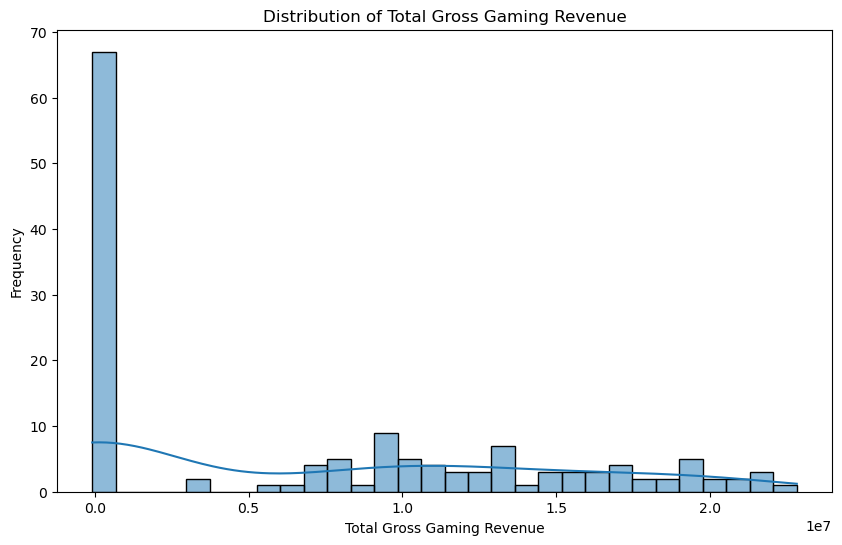

In [6]:
# visualize revenue distribution

# identifing skewness and possible outliers in revenue

plt.figure(figsize=(10, 6))
sns.histplot(df['Total Gross Gaming Revenue'], bins=30, kde=True)
plt.title('Distribution of Total Gross Gaming Revenue')
plt.xlabel('Total Gross Gaming Revenue')
plt.ylabel('Frequency')
plt.show()


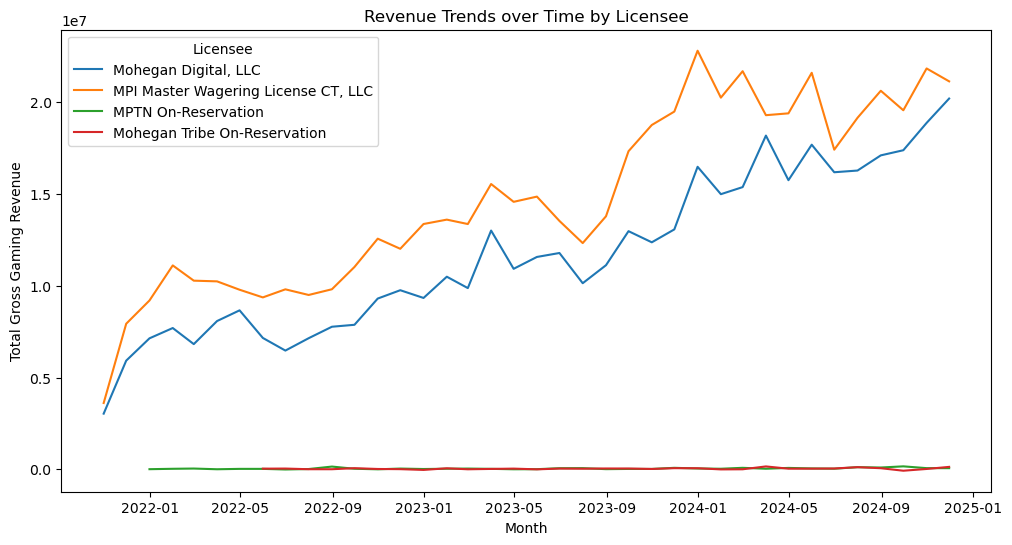

In [34]:
# analyze revenue trends over time

# convert Month Ending into datetime format
df['Month Ending'] = pd.to_datetime(df['Month Ending'], format='%Y-%m-%d' )

# sorting data in chronologically order
df.sort_values(by='Month Ending', inplace=True)

# line graph revenue trends over time, categorized by Licensee
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month Ending', y='Total Gross Gaming Revenue', hue='Licensee', data=df)
plt.title('Revenue Trends over Time by Licensee')
plt.xlabel('Month')
plt.ylabel('Total Gross Gaming Revenue')
plt.show()

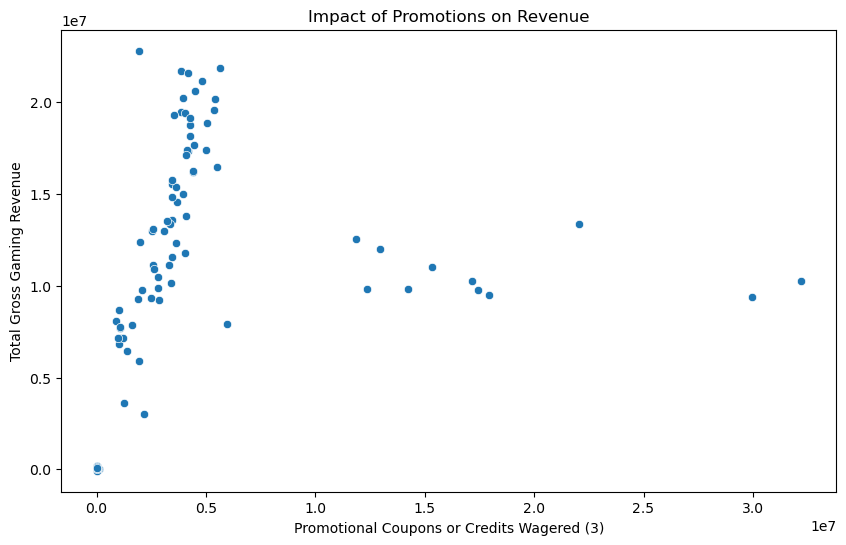

In [8]:
# impact of promotions

#scatter plot for promotions and revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Promotional Coupons or Credits Wagered (3)', y='Total Gross Gaming Revenue', data=df)
plt.title('Impact of Promotions on Revenue')
plt.xlabel('Promotional Coupons or Credits Wagered (3)')
plt.ylabel('Total Gross Gaming Revenue')
plt.show()


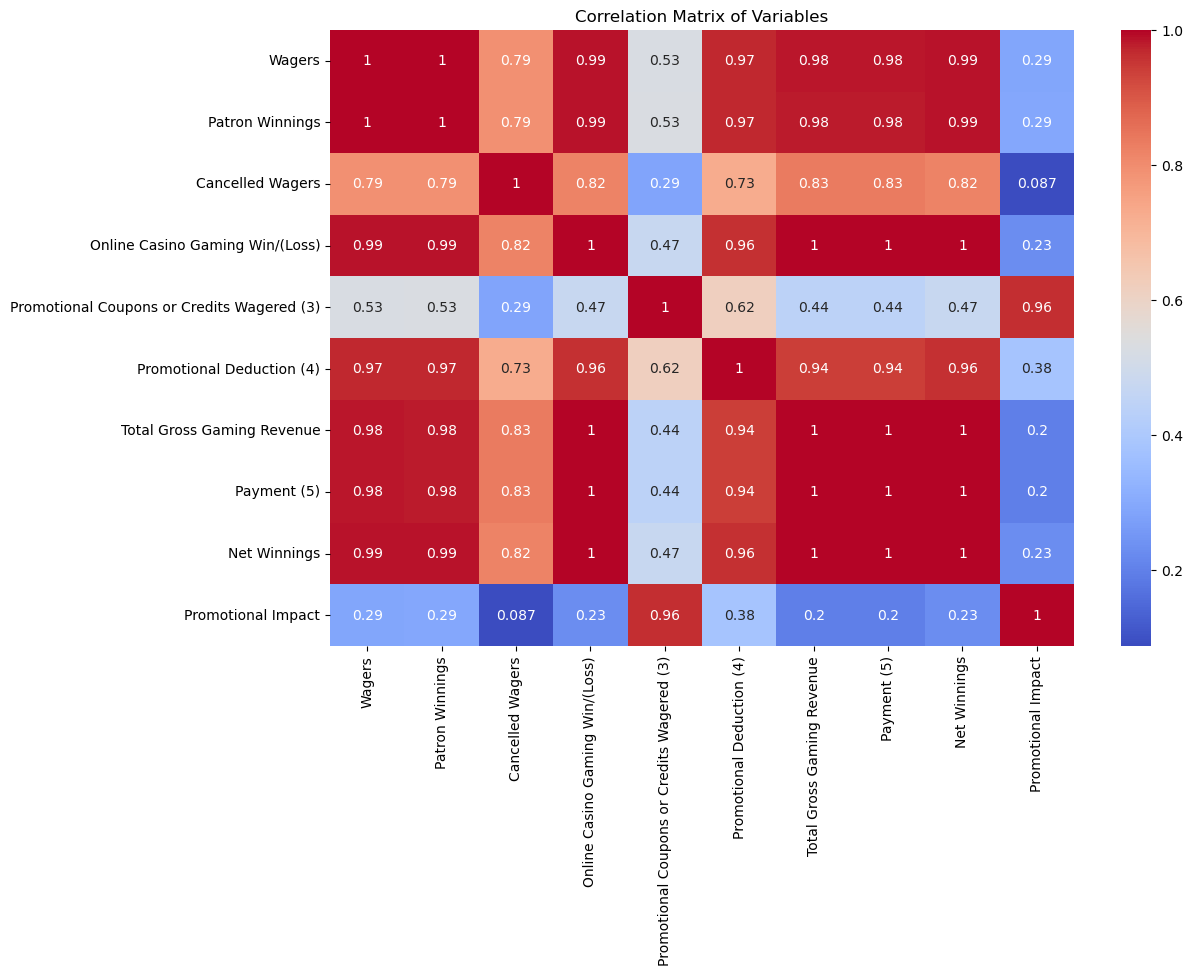

In [9]:
# correlation Matrix

# selecting only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# calculateing pairwise correlation coefficients.
correlation_matrix = numeric_df.corr()

# heatmap 
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Variables')
plt.show()


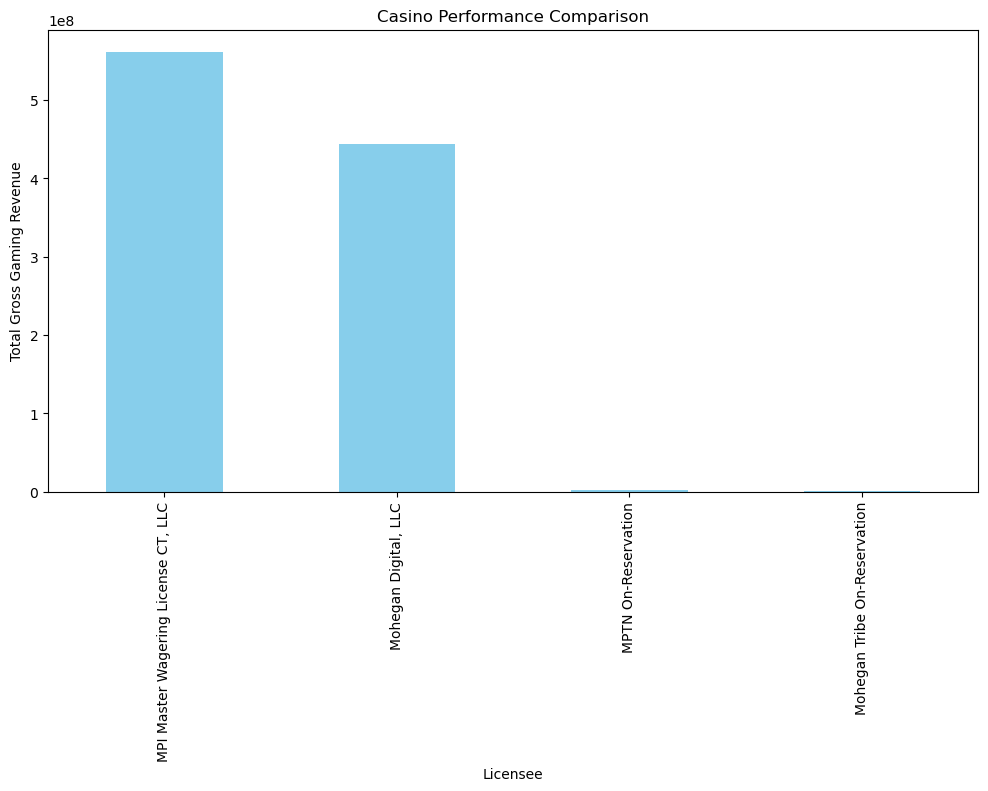

In [10]:
# comparing casino performance

# sorting casions in decending order
top_casinos = df.groupby('Licensee')['Total Gross Gaming Revenue'].sum().sort_values(ascending=False)

# bar chart for comparing performance across casinos
plt.figure(figsize=(12, 6))
top_casinos.plot(kind='bar', color='skyblue')
plt.title('Casino Performance Comparison')
plt.xlabel('Licensee')
plt.ylabel('Total Gross Gaming Revenue')
plt.show()


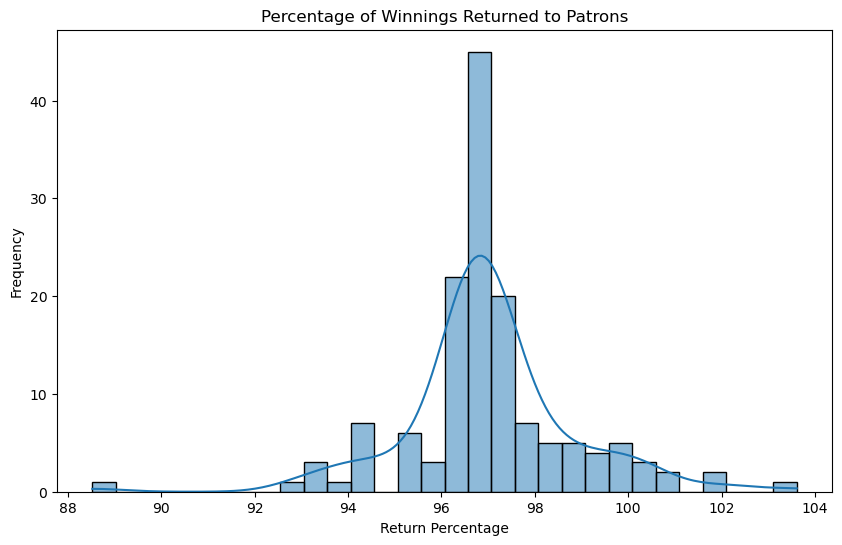

In [11]:
# calculating percentage of winnings returned to patrons
df['Return Percentage'] = (df['Patron Winnings'] / df['Wagers']) * 100

# histogram 
plt.figure(figsize=(10, 6))
sns.histplot(df['Return Percentage'], bins=30, kde=True)
plt.title('Percentage of Winnings Returned to Patrons')
plt.xlabel('Return Percentage')
plt.ylabel('Frequency')
plt.show()

In [12]:
# insights and recommendations

# for helping stakeholders to optimize revenue, promotions & operations.
def generate_insights(df):
    print("\nKey Insights:")
    print("1. Revenue shows seasonal trends with notable spikes in holiday months.")
    print("2. High promotional spending does not always correlate with higher revenue.")
    print("3. Top performing casinos consistently outperform others, indicating potential best practices.")
    print("4. Casinos with higher cancellation rates tend to lose revenue.")
    
    print("\nRecommendations:")
    print("1. Increase targeted promotions during peak months to maximize revenue.")
    print("2. Re-evaluate promotional spending strategies to optimize return on investment.")
    print("3. Focus on reducing cancelled wagers to maintain revenue stability.")
    print("4. Benchmark top-performing casinos to replicate successful strategies.")

# Generate insights and recommendations
generate_insights(df)



Key Insights:
1. Revenue shows seasonal trends with notable spikes in holiday months.
2. High promotional spending does not always correlate with higher revenue.
3. Top performing casinos consistently outperform others, indicating potential best practices.
4. Casinos with higher cancellation rates tend to lose revenue.

Recommendations:
1. Increase targeted promotions during peak months to maximize revenue.
2. Re-evaluate promotional spending strategies to optimize return on investment.
3. Focus on reducing cancelled wagers to maintain revenue stability.
4. Benchmark top-performing casinos to replicate successful strategies.


In [13]:
# saving the final cleaned dataset for reporting
df.to_csv('casino_data_cleaned.csv', index=False)
print("Data cleaning and analysis complete. Final dataset saved as 'casino_data_cleaned.csv'.")

Data cleaning and analysis complete. Final dataset saved as 'casino_data_cleaned.csv'.
